In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Churn_Modelling.csv')
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
df.describe(include="all")

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2932,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Smith,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,32,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,1.569094e+07,NaN,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,NaN,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,NaN,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


In [5]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
df.columns = df.columns.str.replace("Exited","Churned")

In [7]:
df["Age"].min(), df["Age"].max()

(18, 92)

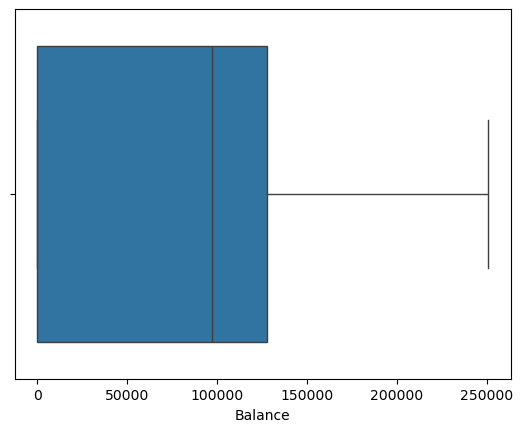

In [8]:
sns.boxplot(x=df["Balance"])
plt.show()

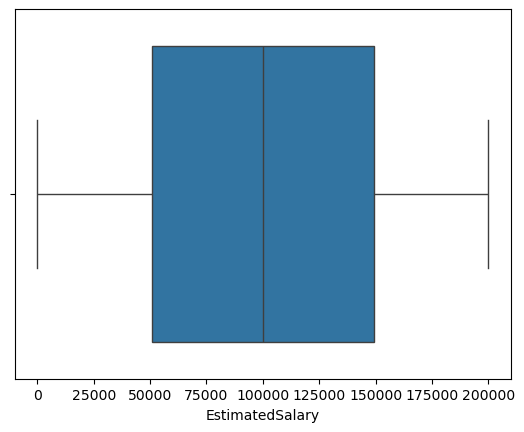

In [9]:
sns.boxplot(x=df["EstimatedSalary"])
plt.show()

In [10]:
df["Churned"].value_counts()

Churned
0    7963
1    2037
Name: count, dtype: int64

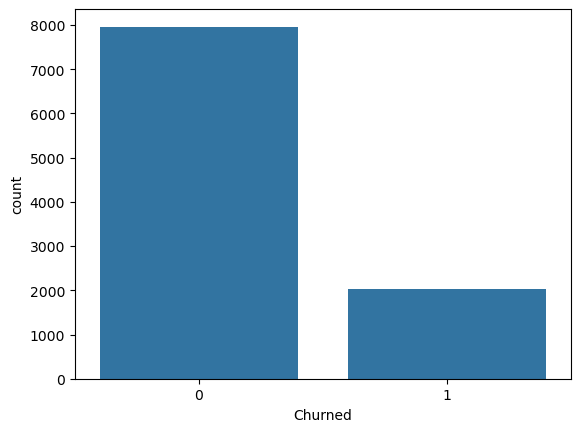

In [11]:
sns.countplot(x="Churned", data=df)
plt.show()

In [12]:
df["Gender"].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

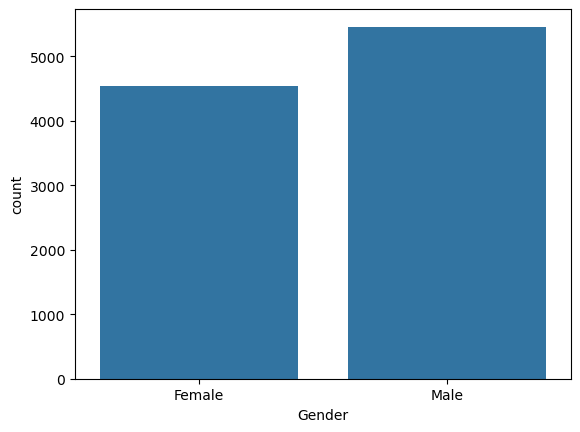

In [13]:
sns.countplot(x="Gender", data=df)
plt.show()

In [14]:
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [15]:
df["Age"].describe()

count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64

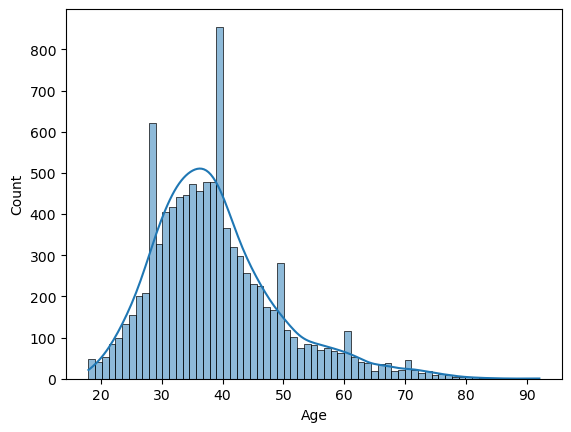

In [16]:
sns.histplot(df["Age"], kde=True)
plt.show()

In [17]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[18, 60, 100],
    labels=["Young", "Old"]
)

In [18]:
df["Age_Group"].value_counts()

Age_Group
Young    9514
Old       464
Name: count, dtype: int64

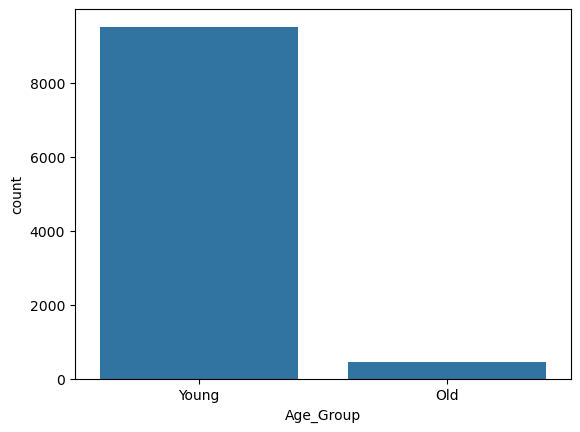

In [19]:
sns.countplot(x="Age_Group", data=df)
plt.show()

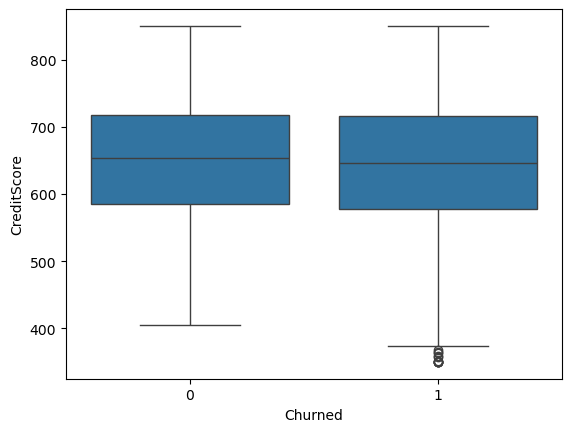

In [20]:
sns.boxplot(x="Churned", y="CreditScore", data=df)
plt.show()

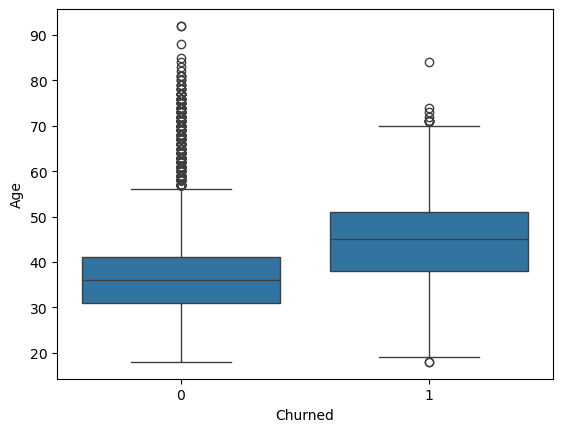

In [21]:
sns.boxplot(x="Churned", y="Age", data=df)
plt.show()

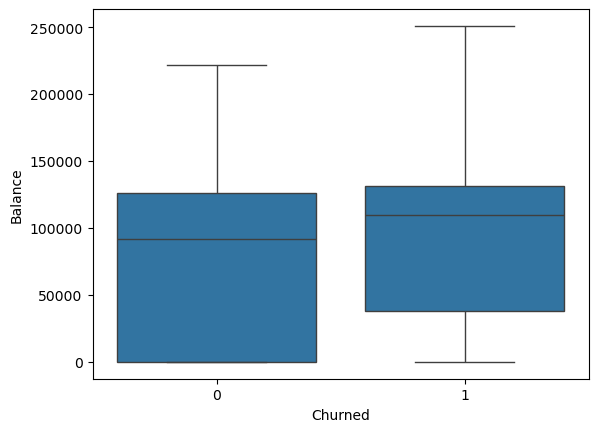

In [22]:
sns.boxplot(x="Churned", y="Balance", data=df)
plt.show()

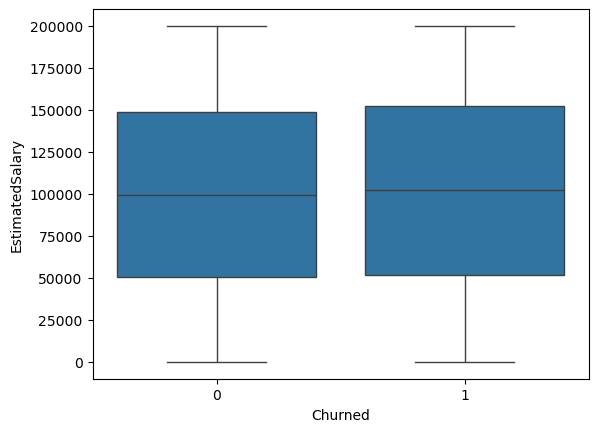

In [23]:
sns.boxplot(x="Churned", y="EstimatedSalary", data=df)
plt.show()

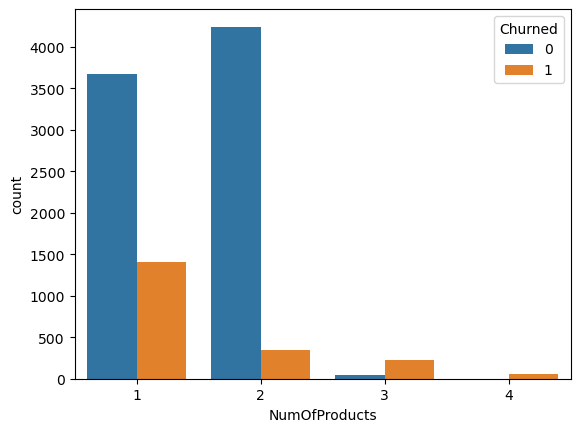

In [24]:
sns.countplot(x="NumOfProducts", hue="Churned", data=df)
plt.show()

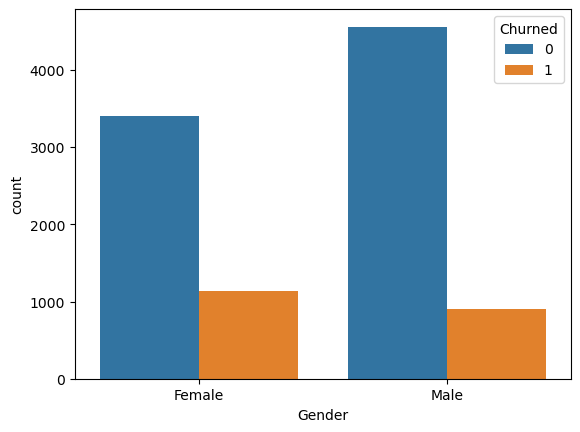

In [25]:
sns.countplot(x="Gender", hue="Churned", data=df)
plt.show()

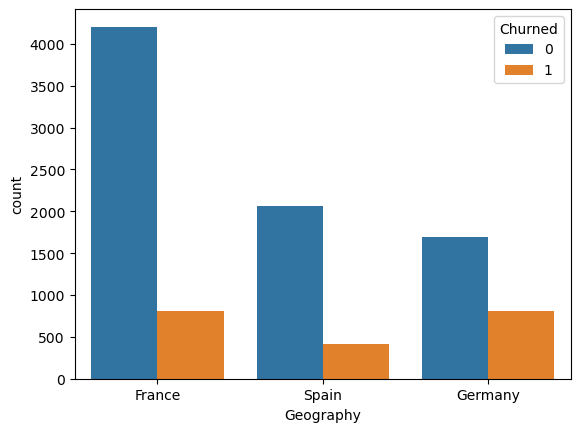

In [26]:
sns.countplot(x="Geography", hue="Churned", data=df)
plt.show()

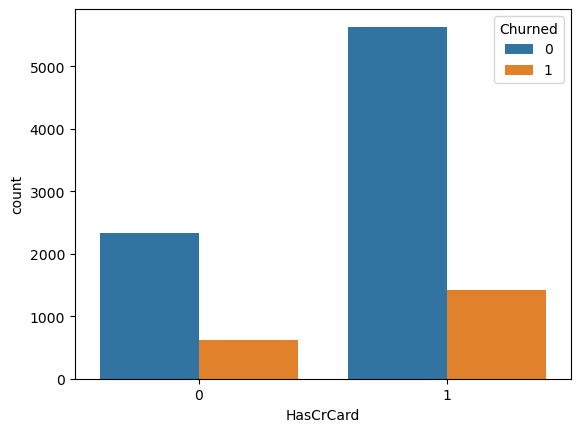

In [27]:
sns.countplot(x="HasCrCard", hue="Churned", data=df)
plt.show()

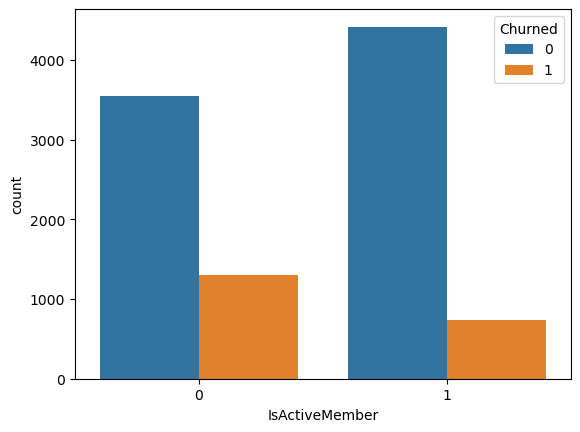

In [28]:
sns.countplot(x="IsActiveMember", hue="Churned", data=df)
plt.show()

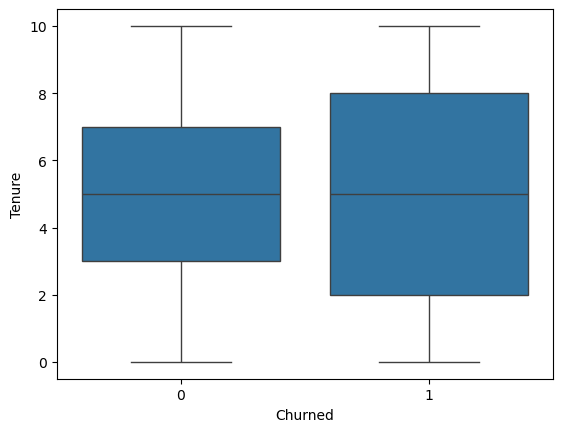

In [29]:
sns.boxplot(x="Churned", y="Tenure", data=df)
plt.show()

In [30]:
df.groupby("HasCrCard")["Churned"].mean()

HasCrCard
0    0.208149
1    0.201843
Name: Churned, dtype: float64

In [31]:
pip install pymysql

Note: you may need to restart the kernel to use updated packages.


In [33]:
import pandas as pd
from sqlalchemy import create_engine

# Read dataset
df = pd.read_csv("Churn_Modelling.csv")

# MySQL connection details
username = "root"
password = "sai2004"
host = "localhost"
port = "3306"
database = "bank_customer_analysis"

# Create connection
engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

# Upload dataframe to MySQL
df.to_sql(
    name="customer_churn",
    con=engine,
    if_exists="replace",
    index=False
)

print("Data uploaded successfully!")

Data uploaded successfully!
